In [ ]:
# Cell 1a
# Install what we need (librosa = audio processing, soundfile = audio I/O)
!pip install librosa soundfile torch torchaudio scikit-learn matplotlib -q

In [ ]:
# Standard library
import os  # noqa: E402
import random  # noqa: E402
import pickle  # noqa: E402

# Third-party
import numpy as np  # noqa: E402
import librosa  # noqa: E402
import librosa.display  # noqa: E402
import matplotlib.pyplot as plt  # noqa: E402
import kagglehub  # noqa: E402
import torch  # noqa: E402
from torch.utils.data import Dataset, DataLoader  # noqa: E402
import torch.nn as nn  # noqa: E402
import torch.nn.functional as F  # noqa: E402
import torch.optim as optim  # noqa: E402

In [ ]:
# Store the Kaggle API token where kagglehub expects to find it
!mkdir -p ~/.kaggle
!echo "KGAT_bbb77dceb1d5cf75ad61e07a205d1b4e" > ~/.kaggle/access_token
!chmod 600 ~/.kaggle/access_token

# Install kagglehub (Kaggle's current recommended library for downloads)
!pip install -q kagglehub

# Download the dataset — this also auto-extracts it

path = kagglehub.dataset_download("kongaevans/speaker-recognition-dataset")
print("Dataset downloaded to:", path)

100%|██████████| 231M/231M [00:11<00:00, 20.9MB/s]

Extracting files...


Dataset downloaded to: /root/.cache/kagglehub/datasets/kongaevans/speaker-recognition-dataset/versions/1


In [ ]:
DATA_ROOT = path  # from Cell 2

# If the dataset has a nested folder (common with Kaggle downloads), step into it
contents = os.listdir(DATA_ROOT)
print("Top-level contents:", contents)

if "16000_pcm_speeches" in contents:
    DATA_ROOT = os.path.join(DATA_ROOT, "16000_pcm_speeches")

print("Using DATA_ROOT:", DATA_ROOT)
print("Contents of DATA_ROOT:", os.listdir(DATA_ROOT))

Top-level contents: ['16000_pcm_speeches']
Using DATA_ROOT: /root/.cache/kagglehub/datasets/kongaevans/speaker-recognition-dataset/versions/1/16000_pcm_speeches
Contents of DATA_ROOT: ['Benjamin_Netanyau', '_background_noise_', 'other', 'tf_Wav_reader.py', 'Magaret_Tarcher', 'Nelson_Mandela', 'Julia_Gillard', 'Jens_Stoltenberg']


In [ ]:
# Cell 4
speakers = [
    d
    for d in os.listdir(DATA_ROOT)
    if os.path.isdir(os.path.join(DATA_ROOT, d))
    and d not in ["_background_noise_", "other"]
]

print("Speakers found:", speakers)

for spk in speakers:
    files_in_folder = os.listdir(os.path.join(DATA_ROOT, spk))
    print(f"{spk}: {len(files_in_folder)} clips")

Speakers found: ['Benjamin_Netanyau', 'Magaret_Tarcher', 'Nelson_Mandela', 'Julia_Gillard', 'Jens_Stoltenberg']
Benjamin_Netanyau: 1500 clips
Magaret_Tarcher: 1500 clips
Nelson_Mandela: 1500 clips
Julia_Gillard: 1501 clips
Jens_Stoltenberg: 1500 clips


Speaker: Benjamin_Netanyau
File: 217.wav
Sample rate: 16000 Hz
Duration: 1.00 seconds
Waveform shape: (16000,)
First 10 raw values: [ 0.07620239  0.27416992  0.32147217  0.23706055  0.14196777  0.10162354
 -0.04833984 -0.19869995 -0.25308228 -0.1723938 ]


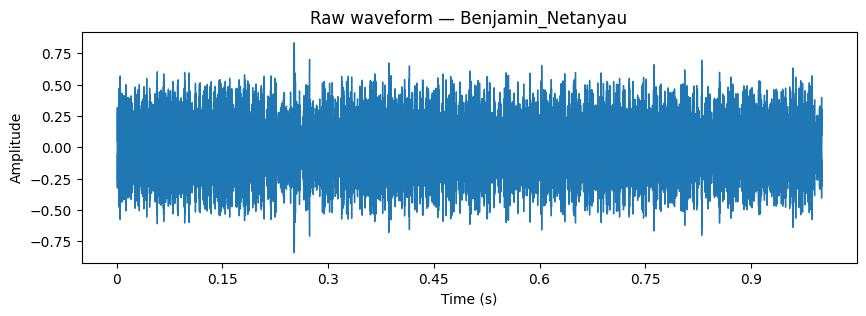

In [ ]:
# Cell 5
sample_speaker = speakers[0]
sample_file = os.listdir(os.path.join(DATA_ROOT, sample_speaker))[0]
sample_path = os.path.join(DATA_ROOT, sample_speaker, sample_file)

# sr=None means "give me the file's original sample rate, don't resample"
waveform, sr = librosa.load(sample_path, sr=None)

print(f"Speaker: {sample_speaker}")
print(f"File: {sample_file}")
print(f"Sample rate: {sr} Hz")
print(f"Duration: {len(waveform)/sr:.2f} seconds")
print(f"Waveform shape: {waveform.shape}")
print(f"First 10 raw values: {waveform[:10]}")

plt.figure(figsize=(10, 3))
librosa.display.waveshow(waveform, sr=sr)
plt.title(f"Raw waveform — {sample_speaker}")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()

In [ ]:
for spk in speakers:
    files = os.listdir(os.path.join(DATA_ROOT, spk))[
        :3
    ]  # check first 3 files per speaker
    for f in files:
        p = os.path.join(DATA_ROOT, spk, f)
        _, sr_check = librosa.load(p, sr=None)
        if sr_check != 16000:
            print(f"⚠️ Mismatch: {spk}/{f} has sample rate {sr_check}")

print("Check complete.")

Check complete.


In [ ]:
# Cell 7
def extract_mfcc(file_path, n_mfcc=40, n_fft=400, hop_length=160, max_len=98):
    """
    Loads one audio file and converts it into a normalized, fixed-size MFCC array.

    Parameters:
        n_mfcc: number of MFCC coefficients to extract per time frame (40 gives good detail)
        n_fft: window size in samples for each frequency analysis step (400 samples = 25ms at 16kHz)
        hop_length: how far the window slides forward each step (160 samples = 10ms at 16kHz)
        max_len: fixed number of time frames every output array will have

    Returns:
        A NumPy array of shape (n_mfcc, max_len) — identical shape for every file.
    """
    waveform, sr = librosa.load(file_path, sr=16000)

    mfcc = librosa.feature.mfcc(
        y=waveform, sr=sr, n_mfcc=n_mfcc, n_fft=n_fft, hop_length=hop_length
    )

    # Normalize each coefficient row independently: zero mean, unit variance
    mfcc = (mfcc - mfcc.mean(axis=1, keepdims=True)) / (
        mfcc.std(axis=1, keepdims=True) + 1e-8
    )

    # Pad with zeros or trim so every output has exactly max_len time columns
    if mfcc.shape[1] < max_len:
        pad_width = max_len - mfcc.shape[1]
        mfcc = np.pad(mfcc, ((0, 0), (0, pad_width)), mode="constant")
    else:
        mfcc = mfcc[:, :max_len]

    return mfcc


print("extract_mfcc() function defined.")

extract_mfcc() function defined.


MFCC shape: (40, 98)  (expected: 40 coefficients x 98 time frames)


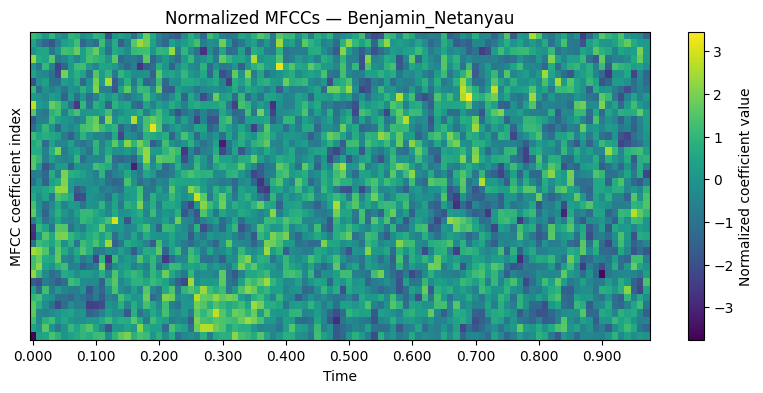

In [ ]:
# Cell 8
mfcc_sample = extract_mfcc(sample_path)
print(f"MFCC shape: {mfcc_sample.shape}  (expected: 40 coefficients x 98 time frames)")

plt.figure(figsize=(10, 4))
librosa.display.specshow(
    mfcc_sample, sr=16000, hop_length=160, x_axis="time", cmap="viridis"
)
plt.colorbar(label="Normalized coefficient value")
plt.title(f"Normalized MFCCs — {sample_speaker}")
plt.ylabel("MFCC coefficient index")
plt.show()

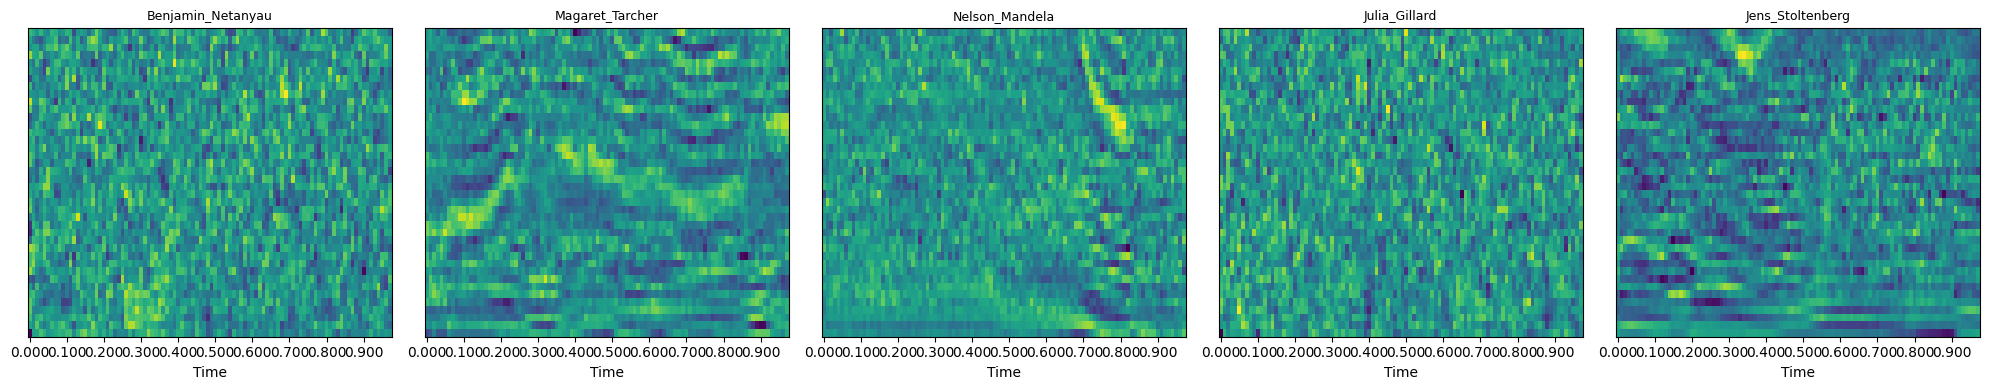

In [ ]:
# Cell 9
fig, axes = plt.subplots(1, len(speakers), figsize=(20, 4))

for i, spk in enumerate(speakers):
    file_name = os.listdir(os.path.join(DATA_ROOT, spk))[0]
    file_path = os.path.join(DATA_ROOT, spk, file_name)

    mfcc_features = extract_mfcc(file_path)

    librosa.display.specshow(
        mfcc_features,
        sr=16000,
        hop_length=160,
        x_axis="time",
        ax=axes[i],
        cmap="viridis",
    )
    axes[i].set_title(spk, fontsize=9)

plt.tight_layout()
plt.show()

In [ ]:
# Cell 10

random.seed(42)  # ensures reproducible splits every time we run this

# Hold one speaker out entirely — never used in training, only for later generalization testing
held_out_speaker = speakers[-1]
training_speakers = [s for s in speakers if s != held_out_speaker]

print(f"Held-out speaker (unseen during training): {held_out_speaker}")
print(f"Speakers used for training/validation: {training_speakers}")

# Build a dictionary: speaker -> {"train": [...file paths...], "val": [...file paths...]}
speaker_files = {}

for spk in training_speakers:
    folder = os.path.join(DATA_ROOT, spk)
    all_files = [
        os.path.join(folder, f) for f in os.listdir(folder) if f.endswith(".wav")
    ]
    random.shuffle(all_files)

    split_idx = int(0.8 * len(all_files))
    speaker_files[spk] = {"train": all_files[:split_idx], "val": all_files[split_idx:]}

    n_train = len(speaker_files[spk]["train"])
    n_val = len(speaker_files[spk]["val"])
    print(f"{spk}: {len(all_files)} total | {n_train} train | {n_val} val")

Held-out speaker (unseen during training): Jens_Stoltenberg
Speakers used for training/validation: ['Benjamin_Netanyau', 'Magaret_Tarcher', 'Nelson_Mandela', 'Julia_Gillard']
Benjamin_Netanyau: 1500 total | 1200 train | 300 val
Magaret_Tarcher: 1500 total | 1200 train | 300 val
Nelson_Mandela: 1500 total | 1200 train | 300 val
Julia_Gillard: 1501 total | 1200 train | 301 val


In [ ]:
# Cell 11
def get_random_triplet(speaker_files, split="train"):
    """
    Returns a tuple of three file paths: (anchor_path, positive_path, negative_path)

    anchor and positive are two different clips from the same speaker.
    negative is a clip from a different speaker.
    """
    speakers_list = list(speaker_files.keys())

    # Pick the anchor/positive speaker
    anchor_speaker = random.choice(speakers_list)
    anchor_path, positive_path = random.sample(speaker_files[anchor_speaker][split], 2)

    # Pick a different speaker for the negative
    negative_speaker = random.choice([s for s in speakers_list if s != anchor_speaker])
    negative_path = random.choice(speaker_files[negative_speaker][split])

    return anchor_path, positive_path, negative_path


# Quick test — generate and inspect one triplet
a, p, n = get_random_triplet(speaker_files, split="train")
print("Anchor:  ", a)
print("Positive:", p)
print("Negative:", n)

Anchor:   /root/.cache/kagglehub/datasets/kongaevans/speaker-recognition-dataset/versions/1/16000_pcm_speeches/Benjamin_Netanyau/1066.wav
Positive: /root/.cache/kagglehub/datasets/kongaevans/speaker-recognition-dataset/versions/1/16000_pcm_speeches/Benjamin_Netanyau/840.wav
Negative: /root/.cache/kagglehub/datasets/kongaevans/speaker-recognition-dataset/versions/1/16000_pcm_speeches/Nelson_Mandela/415.wav


In [ ]:
# Cell 12


class TripletVoiceDataset(Dataset):
    """
    A PyTorch Dataset that generates random (anchor, positive, negative) triplets
    of MFCC features on demand.
    """

    def __init__(self, speaker_files, split="train", num_triplets=2000):
        """
        speaker_files: the dictionary built in Cell 10 (speaker -> {"train": [...], "val": [...]})
        split: "train" or "val" — which file list to draw from
        num_triplets: how many triplets to treat as "one epoch" (doesn't limit actual variety,
                      since each __getitem__ call generates a fresh random triplet)
        """
        self.speaker_files = speaker_files
        self.split = split
        self.num_triplets = num_triplets

    def __len__(self):
        # Tells PyTorch how many items to expect per epoch
        return self.num_triplets

    def __getitem__(self, idx):
        # idx is required by PyTorch's interface, but since triplets are random,
        # we don't actually use idx to look anything up — we just generate a fresh one
        anchor_path, positive_path, negative_path = get_random_triplet(
            self.speaker_files, split=self.split
        )

        anchor_feat = extract_mfcc(anchor_path)
        positive_feat = extract_mfcc(positive_path)
        negative_feat = extract_mfcc(negative_path)

        # Convert from NumPy arrays to PyTorch tensors, and add a "channel" dimension
        # (CNNs expect input shaped as [channels, height, width] — we have 1 channel, like grayscale)
        anchor_tensor = torch.tensor(anchor_feat, dtype=torch.float32).unsqueeze(0)
        positive_tensor = torch.tensor(positive_feat, dtype=torch.float32).unsqueeze(0)
        negative_tensor = torch.tensor(negative_feat, dtype=torch.float32).unsqueeze(0)

        return anchor_tensor, positive_tensor, negative_tensor


print("TripletVoiceDataset class defined.")

TripletVoiceDataset class defined.


In [ ]:
# Cell 13
train_dataset = TripletVoiceDataset(speaker_files, split="train", num_triplets=2000)
val_dataset = TripletVoiceDataset(speaker_files, split="val", num_triplets=500)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=True)

# Pull one batch to inspect
anchor_batch, positive_batch, negative_batch = next(iter(train_loader))

print(f"Anchor batch shape:   {anchor_batch.shape}")  # expect: [32, 1, 40, 98]
print(f"Positive batch shape: {positive_batch.shape}")
print(f"Negative batch shape: {negative_batch.shape}")

Anchor batch shape:   torch.Size([32, 1, 40, 98])
Positive batch shape: torch.Size([32, 1, 40, 98])
Negative batch shape: torch.Size([32, 1, 40, 98])


In [ ]:
# Cell 14


class VoiceEmbeddingNet(nn.Module):
    """
    A CNN that converts an MFCC array (1 x 40 x 98) into a fixed-size embedding vector.
    """

    def __init__(self, embedding_dim=128):
        super(VoiceEmbeddingNet, self).__init__()

        # Convolutional blocks: each one detects patterns, then shrinks the grid size
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)

        self.conv2 = nn.Conv2d(
            in_channels=32, out_channels=64, kernel_size=3, padding=1
        )
        self.bn2 = nn.BatchNorm2d(64)

        self.conv3 = nn.Conv2d(
            in_channels=64, out_channels=128, kernel_size=3, padding=1
        )
        self.bn3 = nn.BatchNorm2d(128)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # After 3 pooling steps, a 40x98 input shrinks down significantly.
        # We compute the flattened size dynamically in forward() to avoid hardcoding it wrong.
        self.fc1 = nn.Linear(128 * 5 * 12, 256)
        self.fc2 = nn.Linear(256, embedding_dim)

    def forward(self, x):
        # Block 1: conv -> batch norm -> activation -> shrink grid
        x = self.pool(F.relu(self.bn1(self.conv1(x))))

        # Block 2
        x = self.pool(F.relu(self.bn2(self.conv2(x))))

        # Block 3
        x = self.pool(F.relu(self.bn3(self.conv3(x))))

        # Flatten the grid into a single long vector per sample
        x = x.view(x.size(0), -1)

        # Compress into the final embedding
        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        # L2 normalize: rescale so each embedding vector has length exactly 1
        x = F.normalize(x, p=2, dim=1)

        return x


print("VoiceEmbeddingNet class defined.")

VoiceEmbeddingNet class defined.


In [ ]:
# Cell 15
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = VoiceEmbeddingNet(embedding_dim=128).to(device)

# Run one batch through the untrained model
anchor_batch = anchor_batch.to(device)
test_output = model(anchor_batch)

print(f"Input shape:  {anchor_batch.shape}")
print(f"Output shape: {test_output.shape}")  # expect: [32, 128]
print(f"Sample embedding (first 10 values): {test_output[0][:10]}")
print(
    f"Embedding vector length (should be ~1.0 due to L2 norm): {test_output[0].norm().item():.4f}"
)

Using device: cuda
Input shape:  torch.Size([32, 1, 40, 98])
Output shape: torch.Size([32, 128])
Sample embedding (first 10 values): tensor([-0.0877,  0.1014, -0.1686,  0.0199, -0.0406,  0.1404,  0.0103,  0.0693,
         0.0846, -0.0228], device='cuda:0', grad_fn=<SliceBackward0>)
Embedding vector length (should be ~1.0 due to L2 norm): 1.0000


In [ ]:
# Cell 16


def triplet_loss(anchor, positive, negative, margin=0.2):
    """
    Computes triplet loss for a batch of embeddings.

    anchor, positive, negative: tensors of shape [batch_size, embedding_dim]
    margin: how much separation we want to enforce between d(A,P) and d(A,N)
    """
    # Euclidean distance between anchor and positive (want this small)
    dist_pos = F.pairwise_distance(anchor, positive, p=2)

    # Euclidean distance between anchor and negative (want this large)
    dist_neg = F.pairwise_distance(anchor, negative, p=2)

    # The core triplet loss formula
    losses = F.relu(dist_pos - dist_neg + margin)

    # Average loss across the batch
    return losses.mean()


# Optimizer: Adam is a standard, reliable choice that adapts the learning rate automatically
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Triplet loss function and optimizer defined.")

Triplet loss function and optimizer defined.


In [ ]:
# Cell 16.5
# Re-create a fresh model and optimizer so we train from scratch with checkpointing this time
model = VoiceEmbeddingNet(embedding_dim=128).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Fresh model and optimizer initialized.")

Fresh model and optimizer initialized.


In [ ]:
num_epochs = 15
best_val_loss = float("inf")
checkpoint_path = "best_voice_embedding_model.pt"

train_losses = []
val_losses = []

for epoch in range(num_epochs):
    # ---- Training phase ----
    model.train()
    running_train_loss = 0.0

    for anchor, positive, negative in train_loader:
        anchor, positive, negative = (
            anchor.to(device),
            positive.to(device),
            negative.to(device),
        )

        optimizer.zero_grad()

        anchor_emb = model(anchor)
        positive_emb = model(positive)
        negative_emb = model(negative)

        loss = triplet_loss(anchor_emb, positive_emb, negative_emb, margin=0.2)

        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()

    avg_train_loss = running_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # ---- Validation phase ----
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad():
        for anchor, positive, negative in val_loader:
            anchor, positive, negative = (
                anchor.to(device),
                positive.to(device),
                negative.to(device),
            )

            anchor_emb = model(anchor)
            positive_emb = model(positive)
            negative_emb = model(negative)

            loss = triplet_loss(anchor_emb, positive_emb, negative_emb, margin=0.2)
            running_val_loss += loss.item()

    avg_val_loss = running_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    # ---- Checkpointing: save weights only when validation loss improves ----
    improved = ""
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), checkpoint_path)
        improved = "  <-- saved (best so far)"

    print(
        f"Epoch {epoch+1}/{num_epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}{improved}"
    )

print(f"\nBest validation loss achieved: {best_val_loss:.4f}")
print(f"Best model saved to: {checkpoint_path}")

Epoch 1/15 | Train Loss: 0.1537 | Val Loss: 0.1350  <-- saved (best so far)
Epoch 2/15 | Train Loss: 0.1286 | Val Loss: 0.1282  <-- saved (best so far)
Epoch 3/15 | Train Loss: 0.1094 | Val Loss: 0.1150  <-- saved (best so far)
Epoch 4/15 | Train Loss: 0.0973 | Val Loss: 0.1257
Epoch 5/15 | Train Loss: 0.0803 | Val Loss: 0.1078  <-- saved (best so far)
Epoch 6/15 | Train Loss: 0.0715 | Val Loss: 0.0918  <-- saved (best so far)
Epoch 7/15 | Train Loss: 0.0686 | Val Loss: 0.0864  <-- saved (best so far)
Epoch 8/15 | Train Loss: 0.0517 | Val Loss: 0.0839  <-- saved (best so far)
Epoch 9/15 | Train Loss: 0.0460 | Val Loss: 0.0907
Epoch 10/15 | Train Loss: 0.0355 | Val Loss: 0.0764  <-- saved (best so far)
Epoch 11/15 | Train Loss: 0.0361 | Val Loss: 0.0793
Epoch 12/15 | Train Loss: 0.0298 | Val Loss: 0.0728  <-- saved (best so far)
Epoch 13/15 | Train Loss: 0.0204 | Val Loss: 0.0584  <-- saved (best so far)
Epoch 14/15 | Train Loss: 0.0198 | Val Loss: 0.0698
Epoch 15/15 | Train Loss: 0.023

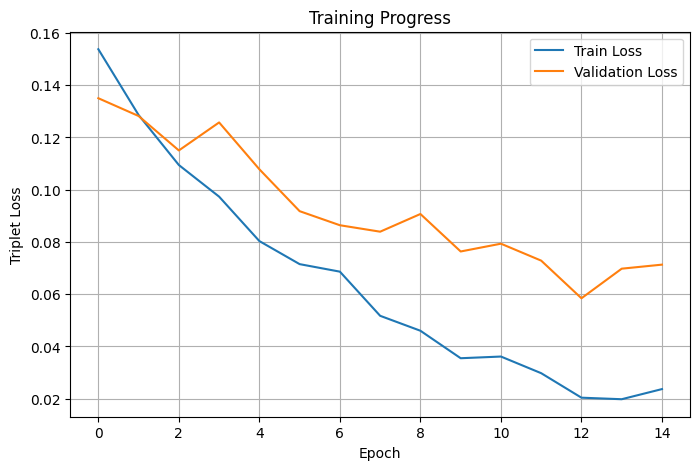

In [ ]:
# Cell 18
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Triplet Loss")
plt.title("Training Progress")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
model.load_state_dict(torch.load(checkpoint_path, map_location=device))
model.eval()  # set to evaluation mode - we're done training, only doing inference from now on

print("Best checkpoint loaded successfully. Model ready for enrollment/authentication.")

Best checkpoint loaded successfully. Model ready for enrollment/authentication.


In [ ]:
# Cell 20
def get_embedding(file_path, model, device):
    """
    Takes a path to an audio file and returns its embedding as a NumPy array.
    """
    mfcc_features = extract_mfcc(file_path)
    tensor = (
        torch.tensor(mfcc_features, dtype=torch.float32).unsqueeze(0).unsqueeze(0)
    )  # add batch + channel dims
    tensor = tensor.to(device)

    with torch.no_grad():  # no need to track gradients, we're not training
        embedding = model(tensor)

    return (
        embedding.cpu().numpy().flatten()
    )  # move back to CPU and convert to a plain NumPy array


# Quick test on one file
test_embedding = get_embedding(sample_path, model, device)
print(f"Embedding shape: {test_embedding.shape}")  # expect: (128,)
print(f"Embedding vector length (should be ~1.0): {np.linalg.norm(test_embedding):.4f}")

Embedding shape: (128,)
Embedding vector length (should be ~1.0): 1.0000


In [ ]:
# Cell 21
def enroll_user(sample_file_paths, model, device):
    """
    Given a list of file paths (multiple recordings from one user),
    returns their averaged, re-normalized voiceprint embedding.
    """
    embeddings = [get_embedding(path, model, device) for path in sample_file_paths]
    embeddings = np.array(embeddings)

    # Average across all provided samples
    voiceprint = embeddings.mean(axis=0)

    # Re-normalize after averaging (averaging can slightly shrink the vector length away from 1.0)
    voiceprint = voiceprint / np.linalg.norm(voiceprint)

    return voiceprint


# Test enrollment: use 5 training clips from Nelson_Mandela as a simulated registration
enrollment_files = speaker_files["Nelson_Mandela"]["train"][:5]
mandela_voiceprint = enroll_user(enrollment_files, model, device)

print(f"Enrolled voiceprint shape: {mandela_voiceprint.shape}")
print(f"Voiceprint vector length: {np.linalg.norm(mandela_voiceprint):.4f}")

Enrolled voiceprint shape: (128,)
Voiceprint vector length: 1.0000


In [ ]:
# Cell 22
def authenticate(new_sample_path, stored_voiceprint, model, device, threshold=0.8):
    """
    Compares a new voice sample against a stored voiceprint.
    Returns (decision: bool, confidence_score: float)
    """
    new_embedding = get_embedding(new_sample_path, model, device)

    # Cosine similarity between two unit-length vectors is just their dot product
    similarity = np.dot(new_embedding, stored_voiceprint)

    decision = similarity >= threshold

    return decision, similarity


# Test 1: a genuine attempt — a DIFFERENT Mandela clip not used during enrollment
genuine_test_file = speaker_files["Nelson_Mandela"]["val"][0]
decision, score = authenticate(
    genuine_test_file, mandela_voiceprint, model, device, threshold=0.8
)
print(
    f"Genuine attempt (real Mandela clip)   -> Accepted: {decision} | Confidence: {score:.4f}"
)

# Test 2: an impostor attempt — a clip from a completely different speaker
impostor_test_file = speaker_files["Benjamin_Netanyau"]["val"][0]
decision, score = authenticate(
    impostor_test_file, mandela_voiceprint, model, device, threshold=0.8
)
print(
    f"Impostor attempt (different speaker)  -> Accepted: {decision} | Confidence: {score:.4f}"
)

# Test 3: an impostor attempt from our held-out speaker (never seen during training at all)
impostor_unseen_file = os.listdir(os.path.join(DATA_ROOT, held_out_speaker))[0]
impostor_unseen_path = os.path.join(DATA_ROOT, held_out_speaker, impostor_unseen_file)
decision, score = authenticate(
    impostor_unseen_path, mandela_voiceprint, model, device, threshold=0.8
)
print(
    f"Impostor attempt (unseen speaker: {held_out_speaker}) -> Accepted: {decision} | Confidence: {score:.4f}"
)

Genuine attempt (real Mandela clip)   -> Accepted: True | Confidence: 0.9971
Impostor attempt (different speaker)  -> Accepted: False | Confidence: 0.6891
Impostor attempt (unseen speaker: Jens_Stoltenberg) -> Accepted: False | Confidence: 0.4684


In [ ]:
# Cell 23
NUM_ENROLLMENT_SAMPLES = 5

voiceprints = {}

for spk in training_speakers:
    enrollment_files = speaker_files[spk]["train"][:NUM_ENROLLMENT_SAMPLES]
    voiceprints[spk] = enroll_user(enrollment_files, model, device)
    print(f"Enrolled {spk} using {NUM_ENROLLMENT_SAMPLES} samples.")

print(f"\nTotal voiceprints stored: {len(voiceprints)}")

Enrolled Benjamin_Netanyau using 5 samples.
Enrolled Magaret_Tarcher using 5 samples.
Enrolled Nelson_Mandela using 5 samples.
Enrolled Julia_Gillard using 5 samples.

Total voiceprints stored: 4


In [ ]:
# Cell 24
NUM_TEST_SAMPLES_PER_SPEAKER = (
    50  # how many clips to test per speaker, for reasonably solid statistics
)

genuine_scores = []
impostor_scores = []

for spk in training_speakers:
    voiceprint = voiceprints[spk]

    # Genuine attempts: other clips from the SAME speaker (from validation set, unseen during enrollment)
    genuine_files = speaker_files[spk]["val"][:NUM_TEST_SAMPLES_PER_SPEAKER]
    for f in genuine_files:
        emb = get_embedding(f, model, device)
        score = np.dot(emb, voiceprint)
        genuine_scores.append(score)

    # Impostor attempts: clips from every OTHER training speaker
    for other_spk in training_speakers:
        if other_spk == spk:
            continue
        impostor_files = speaker_files[other_spk]["val"][
            : NUM_TEST_SAMPLES_PER_SPEAKER // 3
        ]
        for f in impostor_files:
            emb = get_embedding(f, model, device)
            score = np.dot(emb, voiceprint)
            impostor_scores.append(score)

    # Impostor attempts: clips from the held-out, never-trained-on speaker
    held_out_folder = os.path.join(DATA_ROOT, held_out_speaker)
    held_out_files = [
        os.path.join(held_out_folder, f) for f in os.listdir(held_out_folder)
    ][:NUM_TEST_SAMPLES_PER_SPEAKER]
    for f in held_out_files:
        emb = get_embedding(f, model, device)
        score = np.dot(emb, voiceprint)
        impostor_scores.append(score)

genuine_scores = np.array(genuine_scores)
impostor_scores = np.array(impostor_scores)

print(f"Collected {len(genuine_scores)} genuine attempt scores")
print(f"Collected {len(impostor_scores)} impostor attempt scores")
print(
    f"\nGenuine scores  — mean: {genuine_scores.mean():.4f} | std: {genuine_scores.std():.4f}"
)
print(
    f"Impostor scores — mean: {impostor_scores.mean():.4f} | std: {impostor_scores.std():.4f}"
)

Collected 200 genuine attempt scores
Collected 392 impostor attempt scores

Genuine scores  — mean: 0.9323 | std: 0.0738
Impostor scores — mean: 0.6651 | std: 0.2066


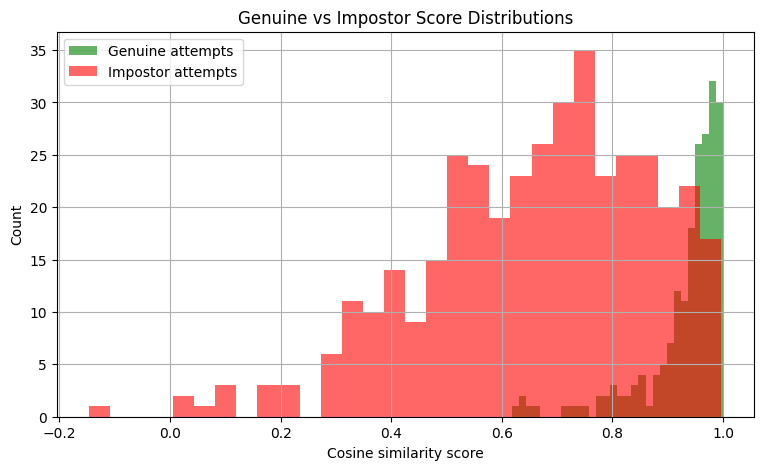

In [ ]:
# Cell 25
plt.figure(figsize=(9, 5))
plt.hist(genuine_scores, bins=30, alpha=0.6, label="Genuine attempts", color="green")
plt.hist(impostor_scores, bins=30, alpha=0.6, label="Impostor attempts", color="red")
plt.xlabel("Cosine similarity score")
plt.ylabel("Count")
plt.title("Genuine vs Impostor Score Distributions")
plt.legend()
plt.grid(True)
plt.show()

Equal Error Rate (EER): 15.03%
Threshold at EER point: 0.88


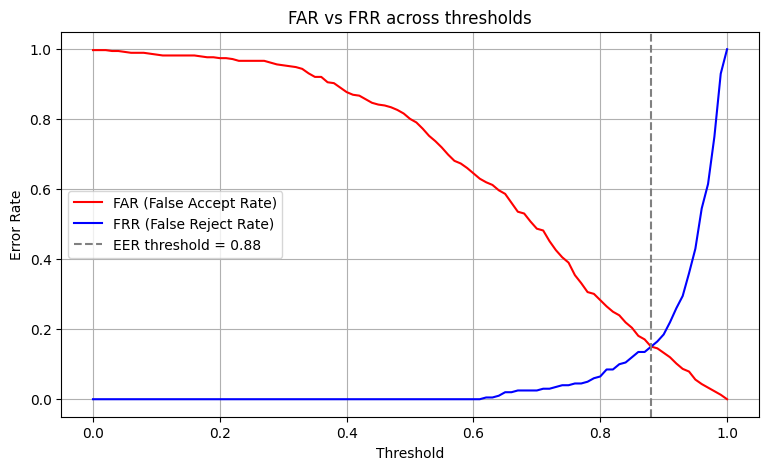

In [ ]:
# Cell 26
thresholds = np.arange(0.0, 1.01, 0.01)

far_list = []
frr_list = []

for t in thresholds:
    far = np.mean(impostor_scores >= t)  # fraction of impostors incorrectly accepted
    frr = np.mean(genuine_scores < t)  # fraction of genuine users incorrectly rejected
    far_list.append(far)
    frr_list.append(frr)

far_list = np.array(far_list)
frr_list = np.array(frr_list)

# Find the threshold where FAR and FRR are closest to each other (the EER point)
diff = np.abs(far_list - frr_list)
eer_idx = np.argmin(diff)
eer_threshold = thresholds[eer_idx]
eer_value = (far_list[eer_idx] + frr_list[eer_idx]) / 2

print(f"Equal Error Rate (EER): {eer_value*100:.2f}%")
print(f"Threshold at EER point: {eer_threshold:.2f}")

# Plot FAR vs FRR across thresholds
plt.figure(figsize=(9, 5))
plt.plot(thresholds, far_list, label="FAR (False Accept Rate)", color="red")
plt.plot(thresholds, frr_list, label="FRR (False Reject Rate)", color="blue")
plt.axvline(
    eer_threshold,
    linestyle="--",
    color="gray",
    label=f"EER threshold = {eer_threshold:.2f}",
)
plt.xlabel("Threshold")
plt.ylabel("Error Rate")
plt.title("FAR vs FRR across thresholds")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Cell 27
FINAL_THRESHOLD = eer_threshold  # 0.90, derived empirically from Cell 26


def authenticate_final(
    new_sample_path, stored_voiceprint, model, device, threshold=FINAL_THRESHOLD
):
    """
    Final authentication function using our empirically-derived threshold.
    Returns (decision: bool, confidence_score: float)
    """
    new_embedding = get_embedding(new_sample_path, model, device)
    similarity = float(np.dot(new_embedding, stored_voiceprint))
    decision = similarity >= threshold
    return decision, similarity


# Re-run our earlier sanity checks with the corrected threshold
genuine_test_file = speaker_files["Nelson_Mandela"]["val"][0]
decision, score = authenticate_final(
    genuine_test_file, voiceprints["Nelson_Mandela"], model, device
)
print(f"Genuine attempt  -> Accepted: {decision} | Confidence: {score:.4f}")

impostor_test_file = speaker_files["Benjamin_Netanyau"]["val"][0]
decision, score = authenticate_final(
    impostor_test_file, voiceprints["Nelson_Mandela"], model, device
)
print(f"Impostor attempt -> Accepted: {decision} | Confidence: {score:.4f}")

Genuine attempt  -> Accepted: True | Confidence: 0.9971
Impostor attempt -> Accepted: False | Confidence: 0.6891


In [ ]:
# Cell 28

# Save voiceprints dictionary
with open("voiceprints.pkl", "wb") as f:
    pickle.dump(voiceprints, f)

# Confirm model checkpoint still exists (saved earlier in Cell 17)
print("Model checkpoint exists:", os.path.exists("best_voice_embedding_model.pt"))
print("Voiceprints saved:", os.path.exists("voiceprints.pkl"))

# Also save the final threshold for reuse
with open("threshold.pkl", "wb") as f:
    pickle.dump(FINAL_THRESHOLD, f)

print(f"Final threshold saved: {FINAL_THRESHOLD}")

Model checkpoint exists: True
Voiceprints saved: True
Final threshold saved: 0.88
